In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df = pd.read_csv('cluster_label_2021_pct_change.csv')

In [8]:
print(df.columns)

Index(['LSOA code', 'ward', 'ward code', 'local authority name',
       'local authority code', 'fullAddress', 'Postcode', 'bathrooms',
       'bedrooms', 'floorAreaSqM', 'livingRooms', 'tenure', 'propertyType',
       'currentEnergyRating', 'Time2', 'saleEstimate_Time2',
       'saleEstimate_confidenceLevel', 'saleEstimate_T1T2Change.percentage',
       'Time1', 'saleEstimate_Time1', 'history_date', 'history_price',
       'Postcode district', 'Latitude', 'Longitude', 'Rural/urban', 'Altitude',
       'London zone', 'Nearest station', 'Distance to station', 'Police force',
       'Average Income', 'Travel To Work Area', 'IMD decile',
       '2021_accommodation type_most_common_type',
       '2021_accommodation type_most_common_prop',
       '2021_Age on arrival in UK_most_common_type',
       '2021_Age on arrival in UK_most_common_prop',
       '2021_cars or vans_most_common_type',
       '2021_cars or vans_most_common_prop',
       '2021_central heating_most_common_type',
       '202

In [10]:
# 예측에 불필요한 컬럼(주소, 코드, 위경도 등) 제거, _prop 도 제거
drop_cols = [
    'LSOA code', 'ward', 'ward code', 'local authority name', 'local authority code',
    'fullAddress', 'Postcode', 'Time2', 'Time1', 'history_date', 'Postcode district',
    'Latitude', 'Longitude', 'Nearest station', 'Police force', 'Travel To Work Area',
    'saleEstimate_confidenceLevel', 'saleEstimate_T1T2Change.percentage',
       'Time1', 'saleEstimate_Time1', 'history_date', 'history_price', 'Time2',
    'is_single_under65',
       'is_highly_qualified_area', 'is_detached', 'cluster',
    'bathrooms',
       'bedrooms', 'floorAreaSqM', 'livingRooms', 'tenure', 'propertyType',
           '2021_accommodation type_most_common_prop',
       '2021_Age on arrival in UK_most_common_prop',
       '2021_cars or vans_most_common_prop',
       '2021_central heating_most_common_prop',
       '2021_Country of birth_most_common_prop',
       '2021_Disability_most_common_prop',
       '2021_Distance traveled to work_most_common_prop',
       '2021_Economic Activity_most_common_prop',
       '2021_English Proficiency_most_common_prop',
       '2021_Ethnic group_most_common_prop',
       '2021_Five year age bands_most_common_prop',
       '2021_General health_most_common_prop',
       '2021_hours worked_most_common_prop',
       '2021_Household composition_most_common_prop',
       '2021_Household deprivation_most_common_prop',
       '2021_Household Language_most_common_prop',
       '2021_Household size_most_common_prop',
       '2021_Method of travel to work_most_common_prop',
       '2021_Multiple ethnic groups_most_common_prop',
       '2021_Multiple religions in household_most_common_prop',
       '2021_NSSEC_most_common_prop',
       '2021_number of bedrooms_most_common_prop',
       '2021_number of rooms_most_common_prop',
       '2021_occupancy rating - bedrooms_most_common_prop',
      '2021_occupation_most_common_prop',
       '2021_Qualifications_most_common_prop',
       '2021_tenure - households_most_common_prop',

]

In [12]:
# 예측에 사용할 타겟 변수와 피처(특징) 선택
# 'saleEstimate_Time2' 를 타겟변수로 잡아야하나..?
target_col = 'saleEstimate_Time2'

In [14]:
gbm_models = {}
X_by_cluster = {}

for cluster_label in df['cluster'].unique():
    print(f'\n Training GBM for Cluster {cluster_label}')
    
    df_cluster = df[df['cluster'] == cluster_label].dropna()
    
    X = df_cluster.drop(drop_cols + [target_col], axis=1)
    X = pd.get_dummies(X, drop_first=True)
    y = df_cluster[target_col]
    
    X_by_cluster[cluster_label] = X.copy()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    
    gbm = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    gbm.fit(X_train, y_train)
    
    gbm_models[cluster_label] = gbm
    
    y_pred = gbm.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    
    print(f'RMSE: {rmse:.2f}')
    print(f'R²: {r2:.2f}')


 Training GBM for Cluster 1


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


RMSE: 452877.10
R²: 0.28

 Training GBM for Cluster 0
RMSE: 1047983.73
R²: 0.34


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


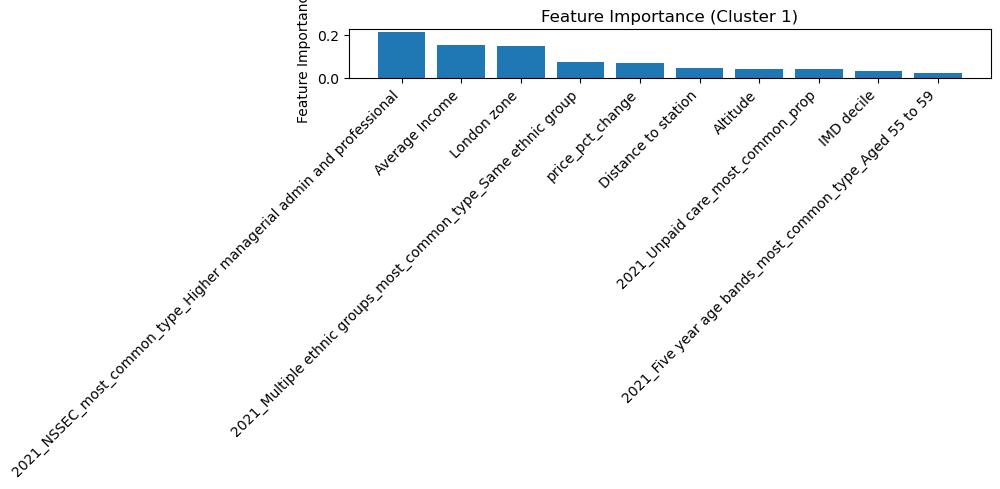

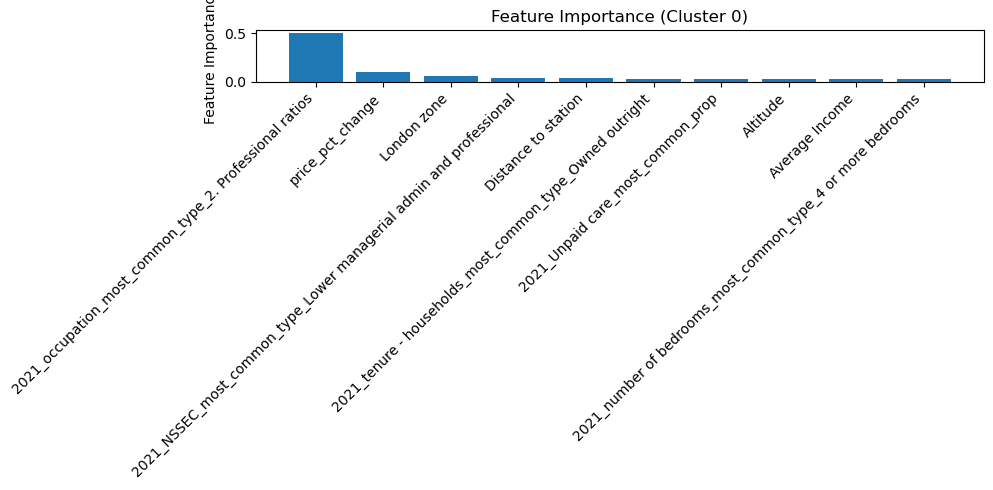

In [16]:
# 변수 중요도 비교 (상위 10개)
import matplotlib.pyplot as plt
import numpy as np

for cluster_label, gbm in gbm_models.items():
    X_cluster = X_by_cluster[cluster_label]
    feature_names = X_cluster.columns
    importances = gbm.feature_importances_
    
    top_indices = np.argsort(importances)[::-1][:10]

    plt.figure(figsize=(10, 5))
    x = np.arange(len(top_indices))
    plt.bar(x, importances[top_indices])
    plt.xticks(x, feature_names[top_indices], rotation=45, ha='right')
    plt.ylabel('Feature Importance')
    plt.title(f'Feature Importance (Cluster {cluster_label})')
    plt.tight_layout()
    plt.show()